In [1]:
from evaluate_classifier import evaluate_classifier


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [3]:
dataset = pd.read_csv("../dataset/cmi_internet_cleaned.csv")


In [4]:
#separating the features from the target variable, sii
X = dataset.drop("sii", axis=1)
y = dataset["sii"]

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import StandardScaler

In [6]:
#do the classical train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [7]:
#standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.svm import LinearSVC

In [11]:
#fit and predict with the linear SVM with different C values
C_values = [0.01, 0.1, 1, 10, 100]
results = defaultdict(list)
for C in C_values:
    svm_model = LinearSVC(C=C, random_state=42, max_iter=10000)
    svm_model.fit(X_train_scaled, y_train)
    y_pred = svm_model.predict(X_test_scaled)

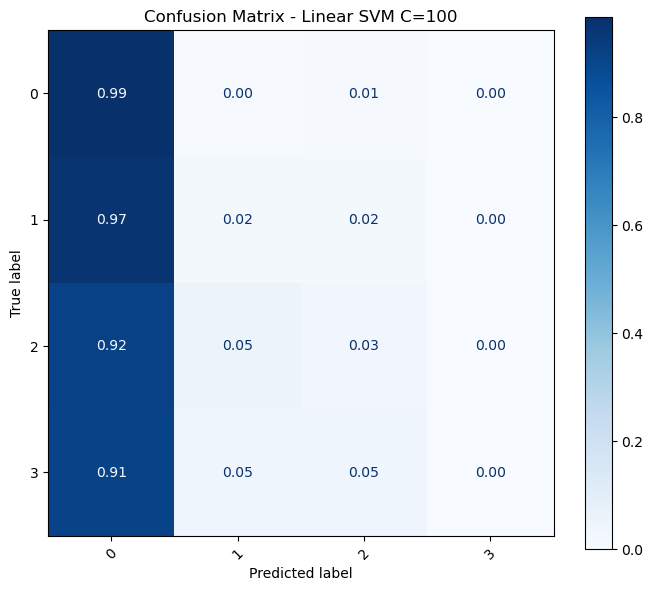


Classification report - Linear SVM C=100


,precision,recall,f1-score,support
0,0.706678,0.985393,0.823081,1643.000000
1,0.250000,0.016166,0.030369,433.000000
2,0.242424,0.031496,0.055749,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.694728,0.694728,0.694728,0.694728
macro avg,0.299776,0.258264,0.227300,2352.000000
weighted avg,0.565858,0.694728,0.586578,2352.000000


In [13]:
# evaluation of the model with all different values of C

results_svm, report_svm = evaluate_classifier(
        model=svm_model,
        X_test=X_test_scaled,
        y_test=y_test,
        model_name=f"Linear SVM C={C}",
        labels=np.sort(y.unique()),
        average="weighted",
        plot_confusion=True,
        plot_roc=False,
        plot_pr=False,
        normalize_cm="true"
    )